In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
data = {
    'ord_no': [
        70001.0,
        np.nan,
        70002.0,
        70004.0,
        np.nan,
        70005.0,
        np.nan,
        70010.0,
        70003.0,
        70012.0,
        np.nan,
        70013.0,
    ],
    'purch_amt': [
        150.50,
        270.65,
        65.26,
        110.50,
        948.50,
        2400.60,
        5760.00,
        1983.43,
        2480.40,
        250.45,
        75.29,
        3045.60,
    ],
    'ord_date': [
        '2012-10-05',
        '2012-09-10',
        np.nan,
        '2012-08-17',
        '2012-09-10',
        '2012-07-27',
        '2012-09-10',
        '2012-10-10',
        '2012-10-10',
        '2012-06-27',
        '2012-08-17',
        '2012-04-25',
    ],
    'customer_id': [
        3002,
        3001,
        3001,
        3003,
        3002,
        3001,
        3001,
        3004,
        3003,
        3002,
        3001,
        3001,
    ],
    'salesman_id': [
        5002.0,
        5003.0,
        5001.0,
        np.nan,
        5002.0,
        5001.0,
        5001.0,
        np.nan,
        5003.0,
        5002.0,
        5003.0,
        np.nan,
    ],
}

df = pd.DataFrame(data)

### 1. Write a Pandas program to detect missing values of a given DataFrame. Display True or False.

In [34]:
df.isna()

,ord_no,purch_amt,ord_date,customer_id,salesman_id
0,False,False,False,False,False
1,True,False,False,False,False
2,False,False,True,False,False
3,False,False,False,False,True
4,True,False,False,False,False
5,False,False,False,False,False
6,True,False,False,False,False
7,False,False,False,False,True
8,False,False,False,False,False
9,False,False,False,False,False


### 2. Write a Pandas program to identify the column(s) of a given DataFrame which have at least one missing value.

In [35]:
df.columns[df.isna().any()]

Index(['ord_no', 'ord_date', 'salesman_id'], dtype='object')

### 3. Write a Pandas program to count the number of missing values in each column of a given DataFrame.

In [36]:
df.isna().sum()

,0
ord_no,4
purch_amt,0
ord_date,1
customer_id,0
salesman_id,3


### 4. Write a Pandas program to find and replace the missing values in a given DataFrame which do not have any valuable information.

In [37]:
df = pd.DataFrame({
    'ord_no': [
        70001,
        np.nan,
        70002,
        70004,
        np.nan,
        70005,
        '--',
        70010,
        70003,
        70012,
        np.nan,
        70013,
    ],
    'purch_amt': [
        150.50,
        270.65,
        65.26,
        110.50,
        948.50,
        2400.60,
        5760.00,
        '?',
        12.43,
        2480.40,
        250.45,
        3045.60,
    ],
    'ord_date': [
        '?',
        '2012-09-10',
        np.nan,
        '2012-08-17',
        '2012-09-10',
        '2012-07-27',
        '2012-09-10',
        '2012-10-10',
        '2012-10-10',
        '2012-06-27',
        '2012-08-17',
        '2012-04-25',
    ],
    'customer_id': [
        3002,
        3001,
        3001,
        3003,
        3002,
        3001,
        3001,
        3004,
        '--',
        3002,
        3001,
        3001,
    ],
    'salesman_id': [
        5002,
        5003,
        '?',
        5001,
        np.nan,
        5002,
        5001,
        '?',
        5003,
        5002,
        5003,
         '--'
    ]
})

df

,ord_no,purch_amt,ord_date,customer_id,salesman_id
0,70001,150.5,?,3002,5002
1,NaN,270.65,2012-09-10,3001,5003
2,70002,65.26,NaN,3001,?
3,70004,110.5,2012-08-17,3003,5001
4,NaN,948.5,2012-09-10,3002,NaN
5,70005,2400.6,2012-07-27,3001,5002
6,--,5760.0,2012-09-10,3001,5001
7,70010,?,2012-10-10,3004,?
8,70003,12.43,2012-10-10,--,5003
9,70012,2480.4,2012-06-27,3002,5002


In [38]:
numeric = ['ord_no', 'purch_amt', 'customer_id','salesman_id']
df[numeric] = df[numeric].apply(pd.to_numeric,errors='coerce')
df['ord_date'] = pd.to_datetime(df['ord_date'],errors='coerce')
df

/tmp/ipykernel_854/3998411217.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ord_date'] = pd.to_datetime(df['ord_date'],errors='coerce')


,ord_no,purch_amt,ord_date,customer_id,salesman_id
0,70001.0,150.50,NaT,3002.0,5002.0
1,NaN,270.65,2012-09-10,3001.0,5003.0
2,70002.0,65.26,NaT,3001.0,NaN
3,70004.0,110.50,2012-08-17,3003.0,5001.0
4,NaN,948.50,2012-09-10,3002.0,NaN
5,70005.0,2400.60,2012-07-27,3001.0,5002.0
6,NaN,5760.00,2012-09-10,3001.0,5001.0
7,70010.0,NaN,2012-10-10,3004.0,NaN
8,70003.0,12.43,2012-10-10,NaN,5003.0
9,70012.0,2480.40,2012-06-27,3002.0,5002.0


### 5. Write a Pandas program to drop the rows where at least one element is missing in a given DataFrame.

In [39]:
df.dropna(axis=0,how='any')

,ord_no,purch_amt,ord_date,customer_id,salesman_id
3,70004.0,110.5,2012-08-17,3003.0,5001.0
5,70005.0,2400.6,2012-07-27,3001.0,5002.0
9,70012.0,2480.4,2012-06-27,3002.0,5002.0


### 6. Write a Pandas program to drop the columns where at least one element is missing in a given DataFrame.

In [40]:
df = pd.DataFrame({
    'ord_no': [70001, np.nan, 70002, 70004, np.nan, 70005, np.nan, 70010, 70003, 70012, np.nan, 70013],
    'purch_amt': [150.50, 270.65, 65.26, 110.50, 948.50, 2400.60, 5760.00, np.nan, 12.43, 2480.40, 250.45, 3045.60],
    'ord_date': [np.nan, '2012-09-10', np.nan, '2012-08-17', '2012-09-10', '2012-07-27', '2012-09-10', '2012-10-10', '2012-10-10', '2012-06-27', '2012-08-17', '2012-04-25'],
    'customer_id': [3002, 3001, 3001, 3003, 3002, 3001, 3001, 3004, np.nan, 3002, 3001, 3001],
    'salesman_id': [5002, 5003, np.nan, 5001, np.nan, 5002, 5001, np.nan, 5003, 5002, 5003, np.nan]
})

df.dropna(how='all')

,ord_no,purch_amt,ord_date,customer_id,salesman_id
0,70001.0,150.50,NaN,3002.0,5002.0
1,NaN,270.65,2012-09-10,3001.0,5003.0
2,70002.0,65.26,NaN,3001.0,NaN
3,70004.0,110.50,2012-08-17,3003.0,5001.0
4,NaN,948.50,2012-09-10,3002.0,NaN
5,70005.0,2400.60,2012-07-27,3001.0,5002.0
6,NaN,5760.00,2012-09-10,3001.0,5001.0
7,70010.0,NaN,2012-10-10,3004.0,NaN
8,70003.0,12.43,2012-10-10,NaN,5003.0
9,70012.0,2480.40,2012-06-27,3002.0,5002.0


### 7. Write a Pandas program to drop the rows where all elements are missing in a given DataFrame.

In [41]:
df = pd.DataFrame({
    'ord_no': [70001, np.nan, 70002, 70004, np.nan, 70005, np.nan, 70010, 70003, 70012, np.nan, 70013],
    'purch_amt': [150.50, 270.65, 65.26, 110.50, 948.50, 2400.60, 5760.00, np.nan, 12.43, 2480.40, 250.45, 3045.60],
    'ord_date': [np.nan, '2012-09-10', np.nan, '2012-08-17', '2012-09-10', '2012-07-27', '2012-09-10', '2012-10-10', '2012-10-10', '2012-06-27', '2012-08-17', '2012-04-25'],
    'customer_id': [3002, 3001, 3001, 3003, 3002, 3001, 3001, 3004, np.nan, 3002, 3001, 3001],
    'salesman_id': [5002, 5003, np.nan, 5001, np.nan, 5002, 5001, np.nan, 5003, 5002, 5003, np.nan]
})

# Drop rows where all elements are missing
df.dropna(how='all')

,ord_no,purch_amt,ord_date,customer_id,salesman_id
0,70001.0,150.50,NaN,3002.0,5002.0
1,NaN,270.65,2012-09-10,3001.0,5003.0
2,70002.0,65.26,NaN,3001.0,NaN
3,70004.0,110.50,2012-08-17,3003.0,5001.0
4,NaN,948.50,2012-09-10,3002.0,NaN
5,70005.0,2400.60,2012-07-27,3001.0,5002.0
6,NaN,5760.00,2012-09-10,3001.0,5001.0
7,70010.0,NaN,2012-10-10,3004.0,NaN
8,70003.0,12.43,2012-10-10,NaN,5003.0
9,70012.0,2480.40,2012-06-27,3002.0,5002.0


### 8. Write a Pandas program to keep the rows with at least 2 NaN values in a given DataFrame.

In [42]:
df = pd.DataFrame({
    'ord_no': [70001, np.nan, 70002, 70004, np.nan, 70005, np.nan, 70010, 70003, 70012, np.nan, 70013],
    'purch_amt': [150.50, 270.65, 65.26, 110.50, 948.50, 2400.60, 5760.00, np.nan, 12.43, 2480.40, 250.45, 3045.60],
    'ord_date': [np.nan, '2012-09-10', np.nan, '2012-08-17', '2012-09-10', '2012-07-27', '2012-09-10', '2012-10-10', '2012-10-10', '2012-06-27', '2012-08-17', '2012-04-25'],
    'customer_id': [3002, 3001, 3001, 3003, 3002, 3001, 3001, 3004, np.nan, 3002, 3001, 3001],
    'salesman_id': [5002, 5003, np.nan, 5001, np.nan, 5002, 5001, np.nan, 5003, 5002, 5003, np.nan]
})

# Keep rows with at least 2 NaN values
df[df.isna().sum(axis=1) >= 2]

,ord_no,purch_amt,ord_date,customer_id,salesman_id
2,70002.0,65.26,NaN,3001.0,NaN
4,NaN,948.50,2012-09-10,3002.0,NaN
7,70010.0,NaN,2012-10-10,3004.0,NaN


### 9. Write a Pandas program to drop those rows which have ‘NaN’ values in specific column(s) of a given DataFrame.

In [43]:
df = pd.DataFrame({
    'ord_no': [70001, np.nan, 70002, 70004, np.nan, 70005, np.nan, 70010, 70003, 70012, np.nan, 70013],
    'purch_amt': [150.50, 270.65, 65.26, 110.50, 948.50, 2400.60, 5760.00, np.nan, 12.43, 2480.40, 250.45, 3045.60],
    'ord_date': [np.nan, '2012-09-10', np.nan, '2012-08-17', '2012-09-10', '2012-07-27', '2012-09-10', '2012-10-10', '2012-10-10', '2012-06-27', '2012-08-17', '2012-04-25'],
    'customer_id': [3002, 3001, 3001, 3003, 3002, 3001, 3001, 3004, np.nan, 3002, 3001, 3001],
    'salesman_id': [5002, 5003, np.nan, 5001, np.nan, 5002, 5001, np.nan, 5003, 5002, 5003, np.nan]
})

# Drop rows with NaN in specific columns
df.dropna(subset=['ord_no', 'customer_id'])

,ord_no,purch_amt,ord_date,customer_id,salesman_id
0,70001.0,150.50,NaN,3002.0,5002.0
2,70002.0,65.26,NaN,3001.0,NaN
3,70004.0,110.50,2012-08-17,3003.0,5001.0
5,70005.0,2400.60,2012-07-27,3001.0,5002.0
7,70010.0,NaN,2012-10-10,3004.0,NaN
9,70012.0,2480.40,2012-06-27,3002.0,5002.0
11,70013.0,3045.60,2012-04-25,3001.0,NaN


### 10. Write a Pandas program to calculate the total number of missing values in a given DataFrame.

In [44]:
df = pd.DataFrame({
    'ord_no': [70001, np.nan, 70002, 70004, np.nan, 70005, np.nan, 70010, 70003, 70012, np.nan, 70013],
    'purch_amt': [150.50, 270.65, 65.26, 110.50, 948.50, 2400.60, 5760.00, np.nan, 12.43, 2480.40, 250.45, 3045.60],
    'ord_date': [np.nan, '2012-09-10', np.nan, '2012-08-17', '2012-09-10', '2012-07-27', '2012-09-10', '2012-10-10', '2012-10-10', '2012-06-27', '2012-08-17', '2012-04-25'],
    'customer_id': [3002, 3001, 3001, 3003, 3002, 3001, 3001, 3004, np.nan, 3002, 3001, 3001],
    'salesman_id': [5002, 5003, np.nan, 5001, np.nan, 5002, 5001, np.nan, 5003, 5002, 5003, np.nan]
})

# Total number of missing values
df.isna().sum().sum()

np.int64(12)

### 11. Write a Pandas program to replace NaNs with a single constant value (e.g., 0) in a given DataFrame.

In [45]:
df = pd.DataFrame({
    'ord_no': [70001, np.nan, 70002, 70004, np.nan, 70005, np.nan, 70010, 70003, 70012, np.nan, 70013],
    'purch_amt': [150.50, 270.65, 65.26, 110.50, 948.50, 2400.60, 5760.00, np.nan, 12.43, 2480.40, 250.45, 3045.60],
    'ord_date': [np.nan, '2012-09-10', np.nan, '2012-08-17', '2012-09-10', '2012-07-27', '2012-09-10', '2012-10-10', '2012-10-10', '2012-06-27', '2012-08-17', '2012-04-25'],
    'customer_id': [3002, 3001, 3001, 3003, 3002, 3001, 3001, 3004, np.nan, 3002, 3001, 3001],
    'salesman_id': [5002, 5003, np.nan, 5001, np.nan, 5002, 5001, np.nan, 5003, 5002, 5003, np.nan]
})

# Replace all NaNs with 0
df.fillna(0)

,ord_no,purch_amt,ord_date,customer_id,salesman_id
0,70001.0,150.50,0,3002.0,5002.0
1,0.0,270.65,2012-09-10,3001.0,5003.0
2,70002.0,65.26,0,3001.0,0.0
3,70004.0,110.50,2012-08-17,3003.0,5001.0
4,0.0,948.50,2012-09-10,3002.0,0.0
5,70005.0,2400.60,2012-07-27,3001.0,5002.0
6,0.0,5760.00,2012-09-10,3001.0,5001.0
7,70010.0,0.00,2012-10-10,3004.0,0.0
8,70003.0,12.43,2012-10-10,0.0,5003.0
9,70012.0,2480.40,2012-06-27,3002.0,5002.0


### 12. Write a Pandas program to replace NaNs with the mean value of a column of a given DataFrame.

In [46]:
df = pd.DataFrame({
    'ord_no': [70001, np.nan, 70002, 70004, np.nan, 70005, np.nan, 70010, 70003, 70012, np.nan, 70013],
    'purch_amt': [150.50, 270.65, 65.26, 110.50, 948.50, 2400.60, 5760.00, np.nan, 12.43, 2480.40, 250.45, 3045.60],
    'ord_date': [np.nan, '2012-09-10', np.nan, '2012-08-17', '2012-09-10', '2012-07-27', '2012-09-10', '2012-10-10', '2012-10-10', '2012-06-27', '2012-08-17', '2012-04-25'],
    'customer_id': [3002, 3001, 3001, 3003, 3002, 3001, 3001, 3004, np.nan, 3002, 3001, 3001],
    'salesman_id': [5002, 5003, np.nan, 5001, np.nan, 5002, 5001, np.nan, 5003, 5002, 5003, np.nan]
})

# Replace NaNs with the mean of the column
df['purch_amt'] = df['purch_amt'].fillna(df['purch_amt'].mean())
df

,ord_no,purch_amt,ord_date,customer_id,salesman_id
0,70001.0,150.500000,NaN,3002.0,5002.0
1,NaN,270.650000,2012-09-10,3001.0,5003.0
2,70002.0,65.260000,NaN,3001.0,NaN
3,70004.0,110.500000,2012-08-17,3003.0,5001.0
4,NaN,948.500000,2012-09-10,3002.0,NaN
5,70005.0,2400.600000,2012-07-27,3001.0,5002.0
6,NaN,5760.000000,2012-09-10,3001.0,5001.0
7,70010.0,1408.626364,2012-10-10,3004.0,NaN
8,70003.0,12.430000,2012-10-10,NaN,5003.0
9,70012.0,2480.400000,2012-06-27,3002.0,5002.0


### 13. Write a Pandas program to replace NaNs with the median value of a column of a given DataFrame.

In [47]:
df = pd.DataFrame({
    'ord_no': [70001, np.nan, 70002, 70004, np.nan, 70005, np.nan, 70010, 70003, 70012, np.nan, 70013],
    'purch_amt': [150.50, 270.65, 65.26, 110.50, 948.50, 2400.60, 5760.00, np.nan, 12.43, 2480.40, 250.45, 3045.60],
    'ord_date': [np.nan, '2012-09-10', np.nan, '2012-08-17', '2012-09-10', '2012-07-27', '2012-09-10', '2012-10-10', '2012-10-10', '2012-06-27', '2012-08-17', '2012-04-25'],
    'customer_id': [3002, 3001, 3001, 3003, 3002, 3001, 3001, 3004, np.nan, 3002, 3001, 3001],
    'salesman_id': [5002, 5003, np.nan, 5001, np.nan, 5002, 5001, np.nan, 5003, 5002, 5003, np.nan]
})

# Replace NaNs with the median of the column
df['purch_amt'] = df['purch_amt'].fillna(df['purch_amt'].median())
df

,ord_no,purch_amt,ord_date,customer_id,salesman_id
0,70001.0,150.50,NaN,3002.0,5002.0
1,NaN,270.65,2012-09-10,3001.0,5003.0
2,70002.0,65.26,NaN,3001.0,NaN
3,70004.0,110.50,2012-08-17,3003.0,5001.0
4,NaN,948.50,2012-09-10,3002.0,NaN
5,70005.0,2400.60,2012-07-27,3001.0,5002.0
6,NaN,5760.00,2012-09-10,3001.0,5001.0
7,70010.0,270.65,2012-10-10,3004.0,NaN
8,70003.0,12.43,2012-10-10,NaN,5003.0
9,70012.0,2480.40,2012-06-27,3002.0,5002.0


### 14. Write a Pandas program to replace NaNs with the most frequent (mode) value of a column of a given DataFrame.

In [48]:
df = pd.DataFrame({
    'ord_no': [70001, np.nan, 70002, 70004, np.nan, 70005, np.nan, 70010, 70003, 70012, np.nan, 70013],
    'purch_amt': [150.50, 270.65, 65.26, 110.50, 948.50, 2400.60, 5760.00, np.nan, 12.43, 2480.40, 250.45, 3045.60],
    'ord_date': [np.nan, '2012-09-10', np.nan, '2012-08-17', '2012-09-10', '2012-07-27', '2012-09-10', '2012-10-10', '2012-10-10', '2012-06-27', '2012-08-17', '2012-04-25'],
    'customer_id': [3002, 3001, 3001, 3003, 3002, 3001, 3001, 3004, np.nan, 3002, 3001, 3001],
    'salesman_id': [5002, 5003, np.nan, 5001, np.nan, 5002, 5001, np.nan, 5003, 5002, 5003, np.nan]
})

# Replace NaNs with the mode of the column
df['customer_id'] = df['customer_id'].fillna(df['customer_id'].mode()[0])
df

,ord_no,purch_amt,ord_date,customer_id,salesman_id
0,70001.0,150.50,NaN,3002.0,5002.0
1,NaN,270.65,2012-09-10,3001.0,5003.0
2,70002.0,65.26,NaN,3001.0,NaN
3,70004.0,110.50,2012-08-17,3003.0,5001.0
4,NaN,948.50,2012-09-10,3002.0,NaN
5,70005.0,2400.60,2012-07-27,3001.0,5002.0
6,NaN,5760.00,2012-09-10,3001.0,5001.0
7,70010.0,NaN,2012-10-10,3004.0,NaN
8,70003.0,12.43,2012-10-10,3001.0,5003.0
9,70012.0,2480.40,2012-06-27,3002.0,5002.0


### 15. Write a Pandas program to interpolate missing values using linear interpolation in a given DataFrame.

In [49]:
df = pd.DataFrame({
    'ord_no': [70001, np.nan, 70002, 70004, np.nan, 70005, np.nan, 70010, 70003, 70012, np.nan, 70013],
    'purch_amt': [150.50, 270.65, 65.26, 110.50, 948.50, 2400.60, 5760.00, np.nan, 12.43, 2480.40, 250.45, 3045.60],
    'ord_date': [np.nan, '2012-09-10', np.nan, '2012-08-17', '2012-09-10', '2012-07-27', '2012-09-10', '2012-10-10', '2012-10-10', '2012-06-27', '2012-08-17', '2012-04-25'],
    'customer_id': [3002, 3001, 3001, 3003, 3002, 3001, 3001, 3004, np.nan, 3002, 3001, 3001],
    'salesman_id': [5002, 5003, np.nan, 5001, np.nan, 5002, 5001, np.nan, 5003, 5002, 5003, np.nan]
})

# Linear interpolation for missing values
df.interpolate(method='linear')

/tmp/ipykernel_854/2964080153.py:10: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(method='linear')


,ord_no,purch_amt,ord_date,customer_id,salesman_id
0,70001.0,150.500,NaN,3002.0,5002.0
1,70001.5,270.650,2012-09-10,3001.0,5003.0
2,70002.0,65.260,NaN,3001.0,5002.0
3,70004.0,110.500,2012-08-17,3003.0,5001.0
4,70004.5,948.500,2012-09-10,3002.0,5001.5
5,70005.0,2400.600,2012-07-27,3001.0,5002.0
6,70007.5,5760.000,2012-09-10,3001.0,5001.0
7,70010.0,2886.215,2012-10-10,3004.0,5002.0
8,70003.0,12.430,2012-10-10,3003.0,5003.0
9,70012.0,2480.400,2012-06-27,3002.0,5002.0


### 16. Write a Pandas program to count the number of missing values in each row of a given DataFrame.

In [50]:
df = pd.DataFrame({
    'ord_no': [70001, np.nan, 70002, 70004, np.nan, 70005, np.nan, 70010, 70003, 70012, np.nan, 70013],
    'purch_amt': [150.50, 270.65, 65.26, 110.50, 948.50, 2400.60, 5760.00, np.nan, 12.43, 2480.40, 250.45, 3045.60],
    'ord_date': [np.nan, '2012-09-10', np.nan, '2012-08-17', '2012-09-10', '2012-07-27', '2012-09-10', '2012-10-10', '2012-10-10', '2012-06-27', '2012-08-17', '2012-04-25'],
    'customer_id': [3002, 3001, 3001, 3003, 3002, 3001, 3001, 3004, np.nan, 3002, 3001, 3001],
    'salesman_id': [5002, 5003, np.nan, 5001, np.nan, 5002, 5001, np.nan, 5003, 5002, 5003, np.nan]
})

# Count missing values in each row
df.isna().sum(axis=1)

,0
0,1
1,1
2,2
3,0
4,2
5,0
6,1
7,2
8,1
9,0


### 17. Write a Pandas program to find the row indices with missing values in a given DataFrame.

In [51]:
df = pd.DataFrame({
    'ord_no': [70001, np.nan, 70002, 70004, np.nan, 70005, np.nan, 70010, 70003, 70012, np.nan, 70013],
    'purch_amt': [150.50, 270.65, 65.26, 110.50, 948.50, 2400.60, 5760.00, np.nan, 12.43, 2480.40, 250.45, 3045.60],
    'ord_date': [np.nan, '2012-09-10', np.nan, '2012-08-17', '2012-09-10', '2012-07-27', '2012-09-10', '2012-10-10', '2012-10-10', '2012-06-27', '2012-08-17', '2012-04-25'],
    'customer_id': [3002, 3001, 3001, 3003, 3002, 3001, 3001, 3004, np.nan, 3002, 3001, 3001],
    'salesman_id': [5002, 5003, np.nan, 5001, np.nan, 5002, 5001, np.nan, 5003, 5002, 5003, np.nan]
})

# Find row indices with missing values
df.index[df.isna().any(axis=1)].tolist()

[0, 1, 2, 4, 6, 7, 8, 10, 11]

### 18. Write a Pandas program to count the number of non-missing values in each column of a given DataFrame.

In [52]:
df = pd.DataFrame({
    'ord_no': [70001, np.nan, 70002, 70004, np.nan, 70005, np.nan, 70010, 70003, 70012, np.nan, 70013],
    'purch_amt': [150.50, 270.65, 65.26, 110.50, 948.50, 2400.60, 5760.00, np.nan, 12.43, 2480.40, 250.45, 3045.60],
    'ord_date': [np.nan, '2012-09-10', np.nan, '2012-08-17', '2012-09-10', '2012-07-27', '2012-09-10', '2012-10-10', '2012-10-10', '2012-06-27', '2012-08-17', '2012-04-25'],
    'customer_id': [3002, 3001, 3001, 3003, 3002, 3001, 3001, 3004, np.nan, 3002, 3001, 3001],
    'salesman_id': [5002, 5003, np.nan, 5001, np.nan, 5002, 5001, np.nan, 5003, 5002, 5003, np.nan]
})

# Count non-missing values in each column
df.notna().sum()

,0
ord_no,8
purch_amt,11
ord_date,10
customer_id,11
salesman_id,8


### 19. Write a Pandas program to select rows from a given DataFrame where a specific column value is missing.

In [53]:
df = pd.DataFrame({
    'ord_no': [70001, np.nan, 70002, 70004, np.nan, 70005, np.nan, 70010, 70003, 70012, np.nan, 70013],
    'purch_amt': [150.50, 270.65, 65.26, 110.50, 948.50, 2400.60, 5760.00, np.nan, 12.43, 2480.40, 250.45, 3045.60],
    'ord_date': [np.nan, '2012-09-10', np.nan, '2012-08-17', '2012-09-10', '2012-07-27', '2012-09-10', '2012-10-10', '2012-10-10', '2012-06-27', '2012-08-17', '2012-04-25'],
    'customer_id': [3002, 3001, 3001, 3003, 3002, 3001, 3001, 3004, np.nan, 3002, 3001, 3001],
    'salesman_id': [5002, 5003, np.nan, 5001, np.nan, 5002, 5001, np.nan, 5003, 5002, 5003, np.nan]
})

# Select rows where 'ord_no' is missing
df[df['ord_no'].isna()]

,ord_no,purch_amt,ord_date,customer_id,salesman_id
1,NaN,270.65,2012-09-10,3001.0,5003.0
4,NaN,948.50,2012-09-10,3002.0,NaN
6,NaN,5760.00,2012-09-10,3001.0,5001.0
10,NaN,250.45,2012-08-17,3001.0,5003.0


### 20. Write a Pandas program to create a heatmap for more information about the distribution of missing values in a given DataFrame.

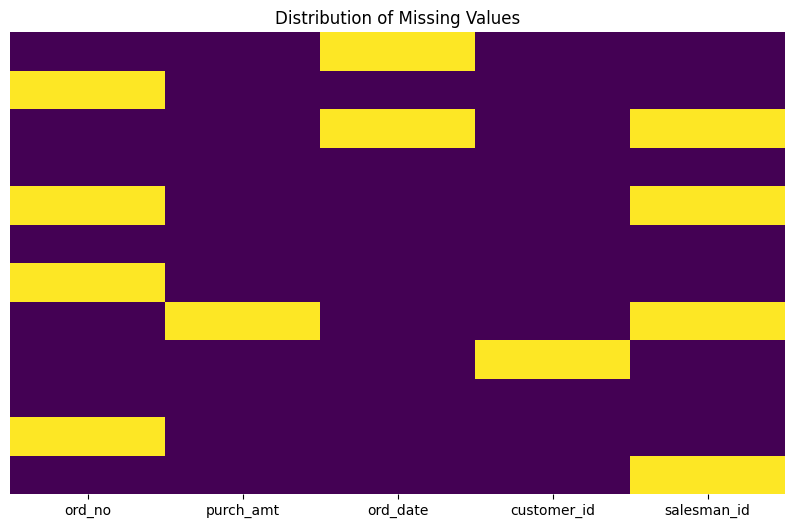

In [54]:
df = pd.DataFrame({
    'ord_no': [70001, np.nan, 70002, 70004, np.nan, 70005, np.nan, 70010, 70003, 70012, np.nan, 70013],
    'purch_amt': [150.50, 270.65, 65.26, 110.50, 948.50, 2400.60, 5760.00, np.nan, 12.43, 2480.40, 250.45, 3045.60],
    'ord_date': [np.nan, '2012-09-10', np.nan, '2012-08-17', '2012-09-10', '2012-07-27', '2012-09-10', '2012-10-10', '2012-10-10', '2012-06-27', '2012-08-17', '2012-04-25'],
    'customer_id': [3002, 3001, 3001, 3003, 3002, 3001, 3001, 3004, np.nan, 3002, 3001, 3001],
    'salesman_id': [5002, 5003, np.nan, 5001, np.nan, 5002, 5001, np.nan, 5003, 5002, 5003, np.nan]
})

# Create a heatmap for missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cmap='viridis', cbar=False, yticklabels=False)
plt.title('Distribution of Missing Values')
plt.show()